In [ ]:
import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/pvc-6/pvc6_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules/')

from pvc6_stim_analysis import *
from pvc6_load_data import *
from pvc6_plotting import *
from spikeparam_plotting import plot_corr_heatmap_only_spk

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from spikeparam.patch.fit import Spike, SpikeGroup
from tqdm.notebook import tqdm
import pickle

import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('white')

import warnings
warnings.filterwarnings('ignore')
import os
import scipy.stats as stats

set_plot_style()

In [2]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles
PICKLE_DIR  = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/"


## 1. Data Source: PVC-6 (CRCNS)

Whole-cell current clamp recordings from mouse visual cortex (in vitro slice), sourced from CRCNS PVC-6. Each cell was driven with three stimulation regimes: constant current, ramp current, and **pink (1/f) noise** — a stochastic broadband stimulus that produces naturalistic, continuously varying drive. Pink noise is the key condition: because the input fluctuates trial-to-trial and moment-to-moment, we can directly ask whether spike waveform features track instantaneous stimulus properties.

## 2. Data Loading & QC

We open the HDF5 recording and extract sweep-level ephys + stimulus traces at 200 kHz. Before anything else we visually inspect one constant-current sweep and one pink-noise sweep — confirming signal quality, spike detection thresholds, and the degree of stimulus variability across sweep types.

In [3]:
fs = 200000 # sampling rate
one_ms = int(fs / 1000)
total_sweeps = 66
filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename
f = h5py.File(filename, 'r')

## 3. Stimulus Labeling & Spike Extraction

### 3a. Cataloguing Stimulus Types and Pink Noise Variants

For each sweep we label the stimulus type (constant / ramp / pink) and, for pink sweeps, extract spectral properties of the noise waveform (exponent, mean, std). This metadata table is the backbone for all downstream sub-group analyses — especially comparing first vs. all pink spikes, and testing whether stimulus statistics predict waveform features.

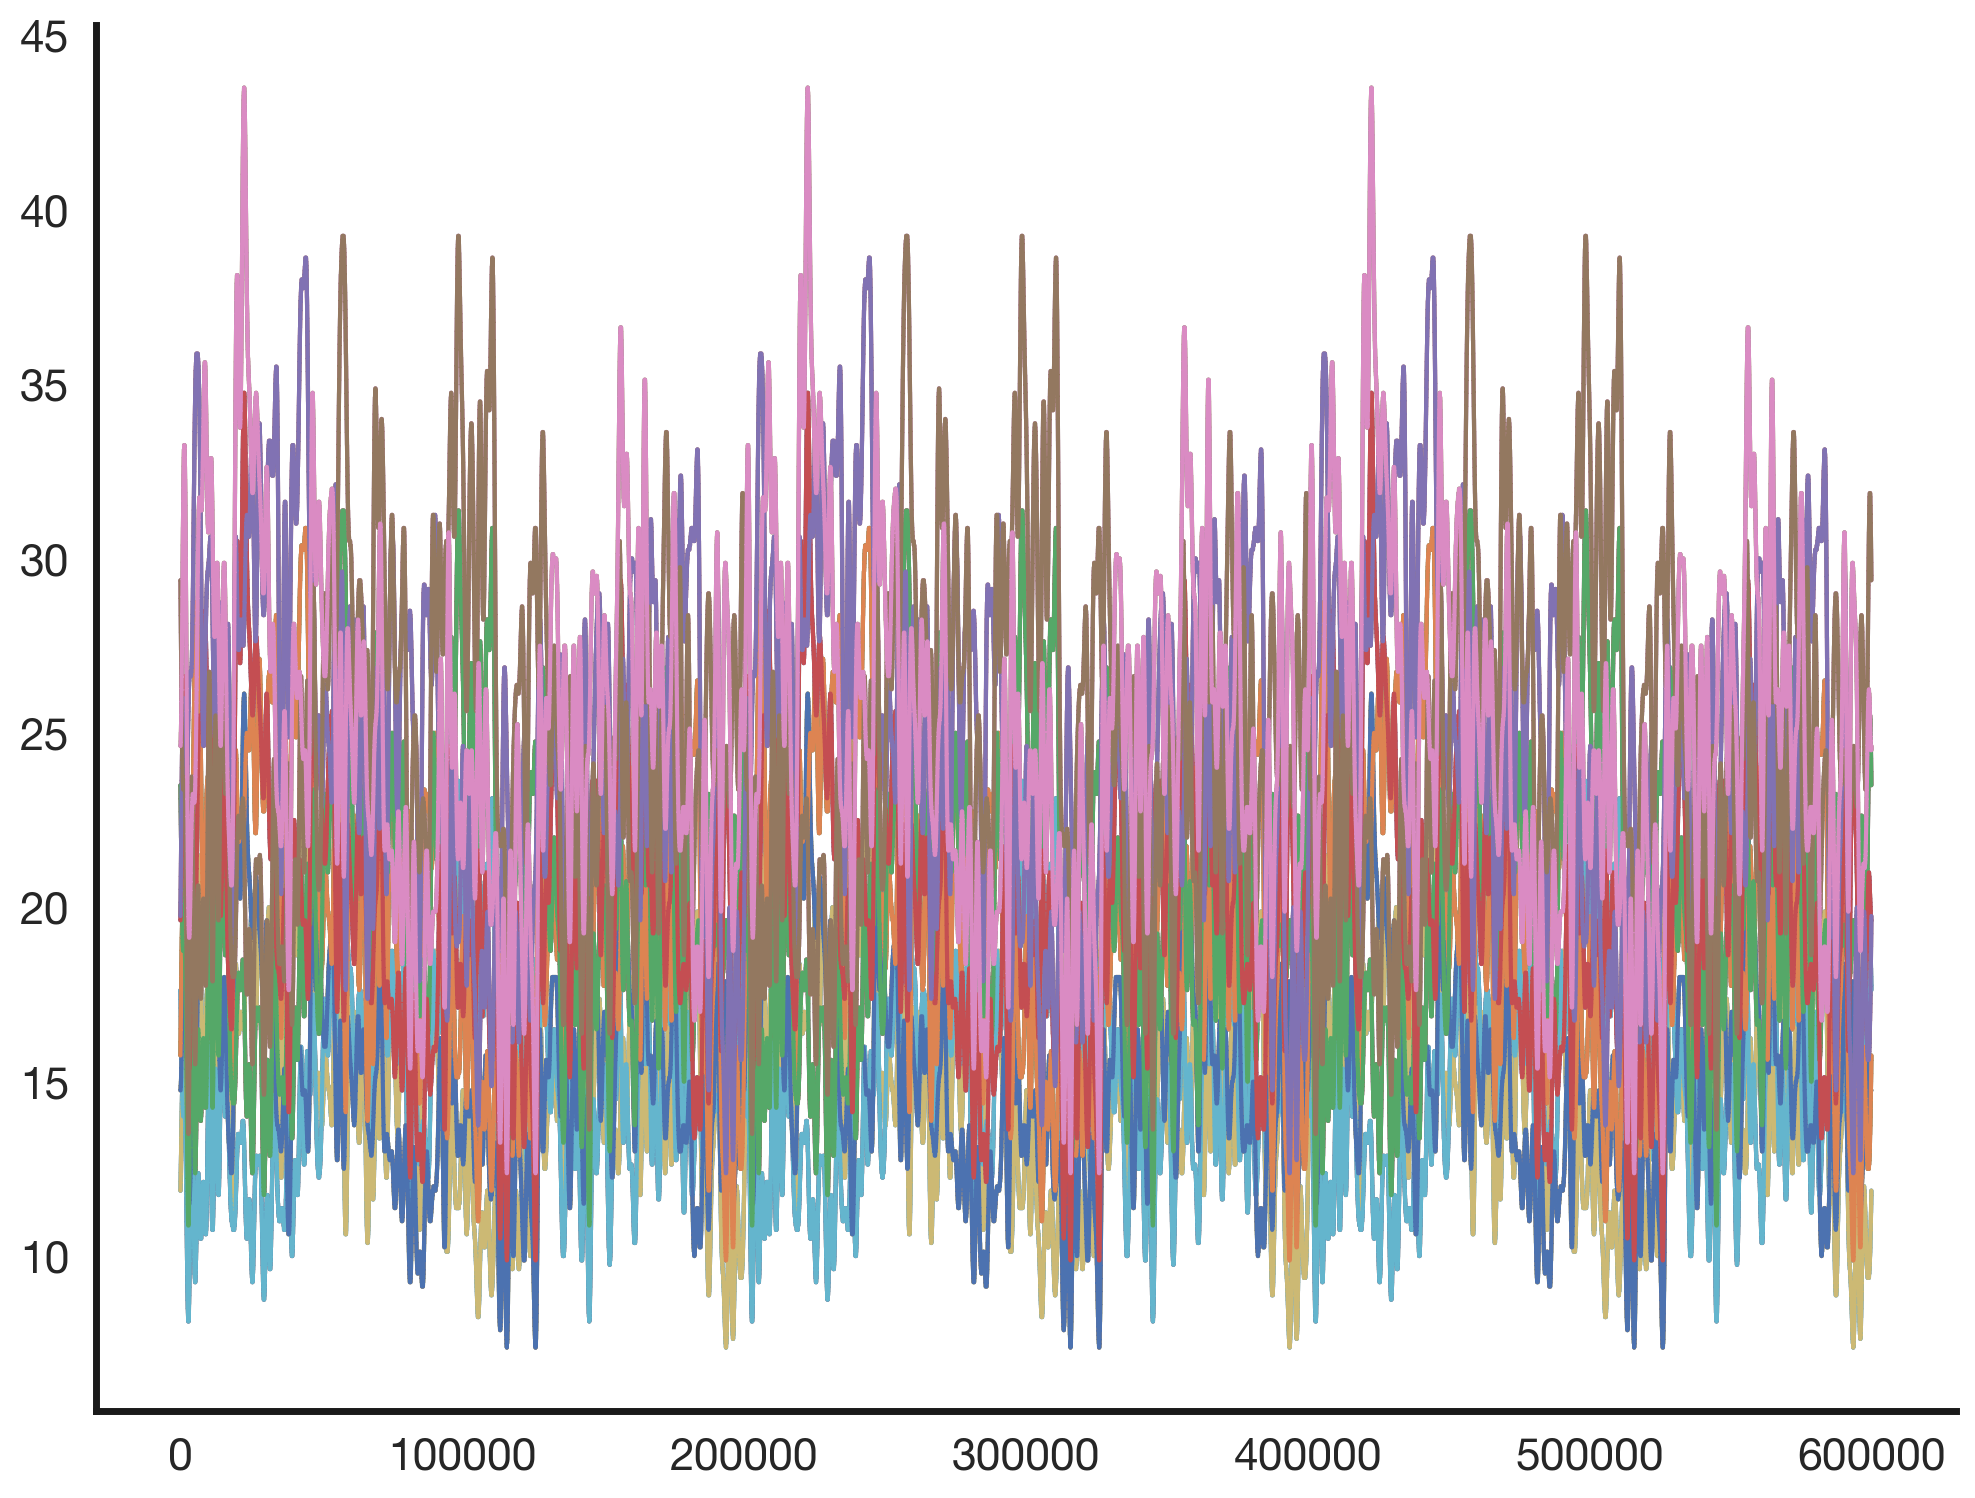

In [4]:
# Process sweeps and extract features
pink_types = process_pink_type_info(f, fs)

### 3b. Processing Sweeps & Loading Pickles

We extract every spike from every sweep, compute per-spike stimulus context (type, sweep index, ISI), and save to pickles for fast reloading. The full dataset is concatenated into `all_data` — a matrix of aligned spike waveforms — for population-level fitting in the next step.

In [5]:
_pickle_paths = {
    'stim': os.path.join(PICKLE_DIR, 'df_stim_features.pkl'),
    'data': os.path.join(PICKLE_DIR, 'all_data.pkl'),
}
df_stim_features, all_data_flat = load_or_compute_cell_data(
    _pickle_paths, FORCE_RERUN,
    n_sweeps=66, f=f, one_ms=one_ms, fs=fs, pink_types=pink_types,
)

pickle_path_waveform = os.path.join(PICKLE_DIR, 'stim_waveforms.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path_waveform):
    try:
        with open(pickle_path_waveform, 'rb') as file:
            stim_waveforms = pickle.load(file)
        all_contant_spks, all_ramp_spks, all_pink_spks = stim_waveforms
        print('Loaded stim_waveforms from pickle.')
    except Exception as _e:
        print(f'stim_waveforms pickle load failed ({_e}); recomputing from all_data.')
        stim_waveforms = None
else:
    stim_waveforms = None

if stim_waveforms is None:
    pink_types_local = process_pink_type_info(f, fs)
    (_, _, _, _, _, _, _, _, _, _, _, _, _,
     _, _, _, all_contant_spks, all_ramp_spks, all_pink_spks
    ) = process_sweeps(66, f, one_ms, fs, pink_types_local, load_sweep, find_spike_times, fit_exp_nonlinear)
    stim_waveforms = [all_contant_spks, all_ramp_spks, all_pink_spks]
    with open(pickle_path_waveform, 'wb') as file:
        pickle.dump(stim_waveforms, file)
    print('Saved stim_waveforms to pickle.')


Loaded df_stim_features and all_data from pickle.
Loaded stim_waveforms from pickle.


## 4. Spike Waveform Parameterization

### 4a. Single Spike Visualization & First Derivative

A sanity check before batch fitting: we plot one spike and its derivative to confirm that parameterization landmarks (threshold, peak, trough, inflection) are being detected correctly. The derivative is essential for identifying inflection points that aren't obvious from the voltage trace alone.

### 4b. Fitting Spike Waveforms

We instantiate a `Spike` object on the full spike matrix and extract: peak amplitude, peak sharpness, peak width, exp_lambda (repolarization rate), exp_const, inflection time, and log ISI — the same feature set used across all datasets, giving us a shared vocabulary for comparing stimulus-driven variability here to spontaneous variability in spe-1.

In [6]:
sp = Spike(thresh_amp= -10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms = 0.5)
sp.fit(all_data_flat, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/820 [00:00<?, ?it/s]

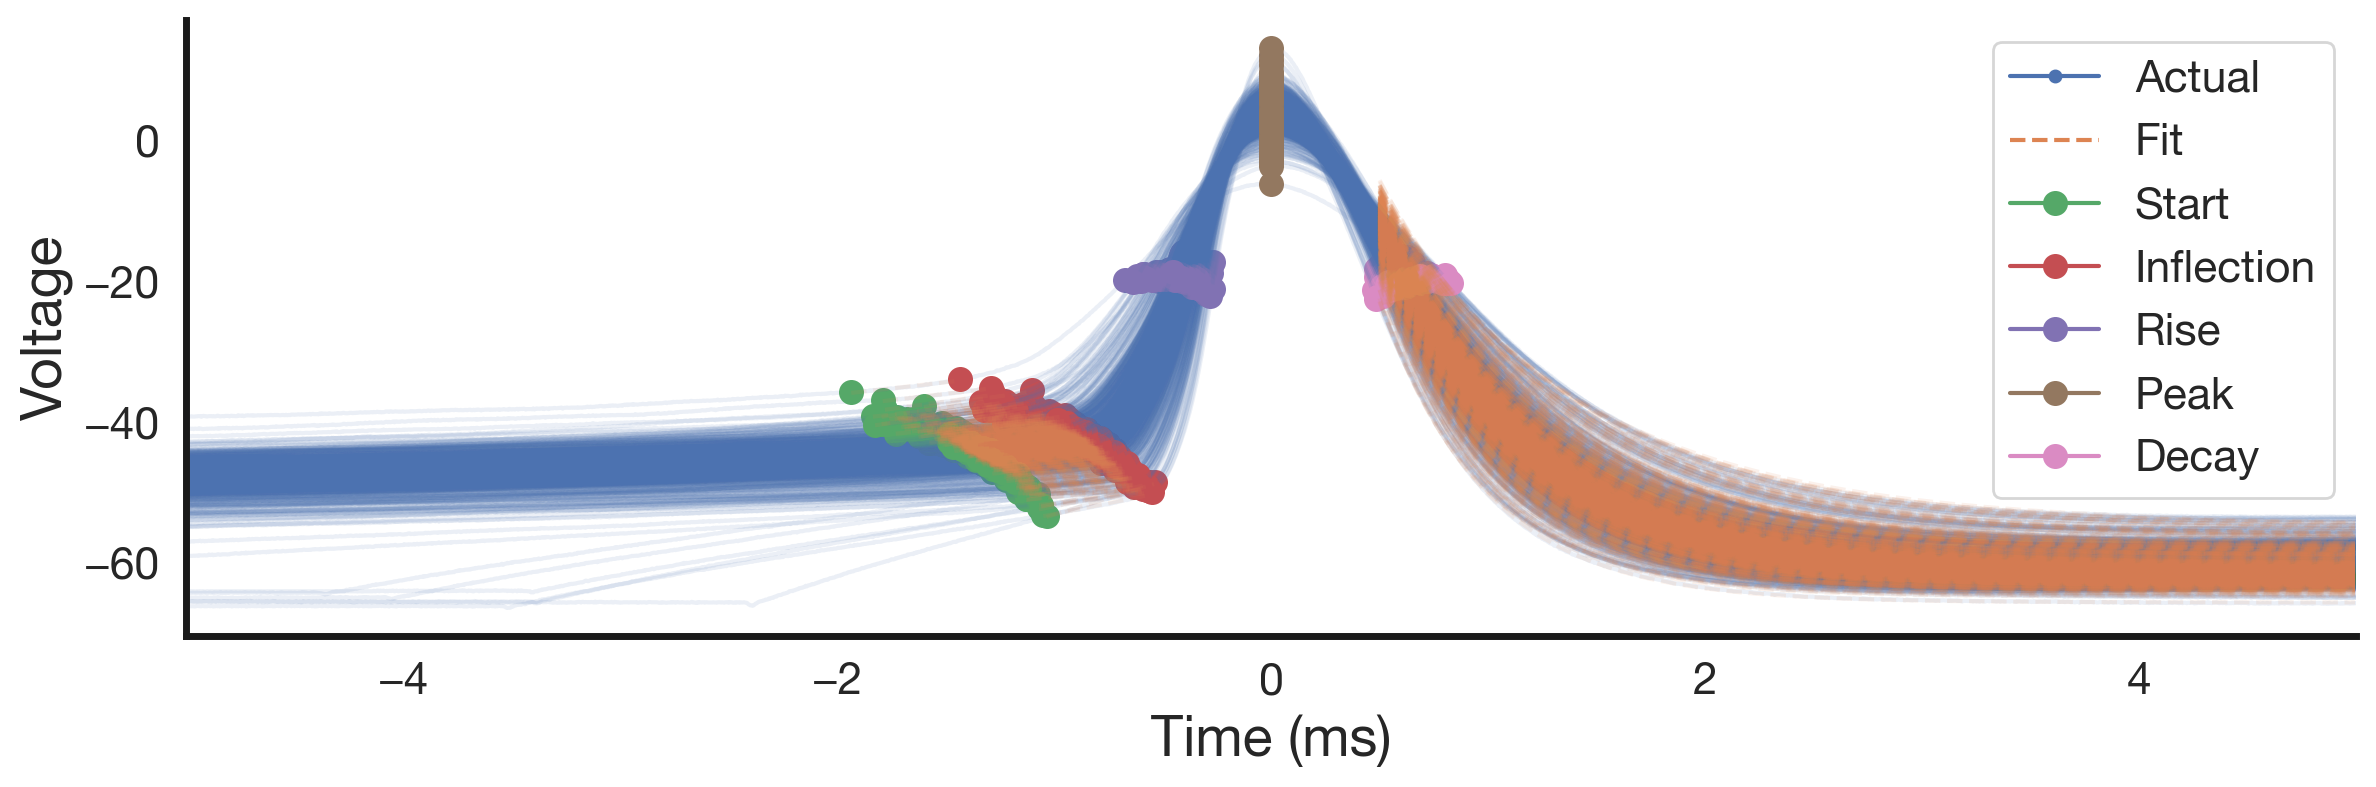

In [7]:
sp.plot(show_points=True)

In [8]:
sp.filter_features()

In [9]:
df_features = sp.df_features

### 4b-i. Fit Quality Distributions

R² histograms for the ramp-amplitude (linear) and exp-decay fits, and distributions of each extracted spike waveform feature.

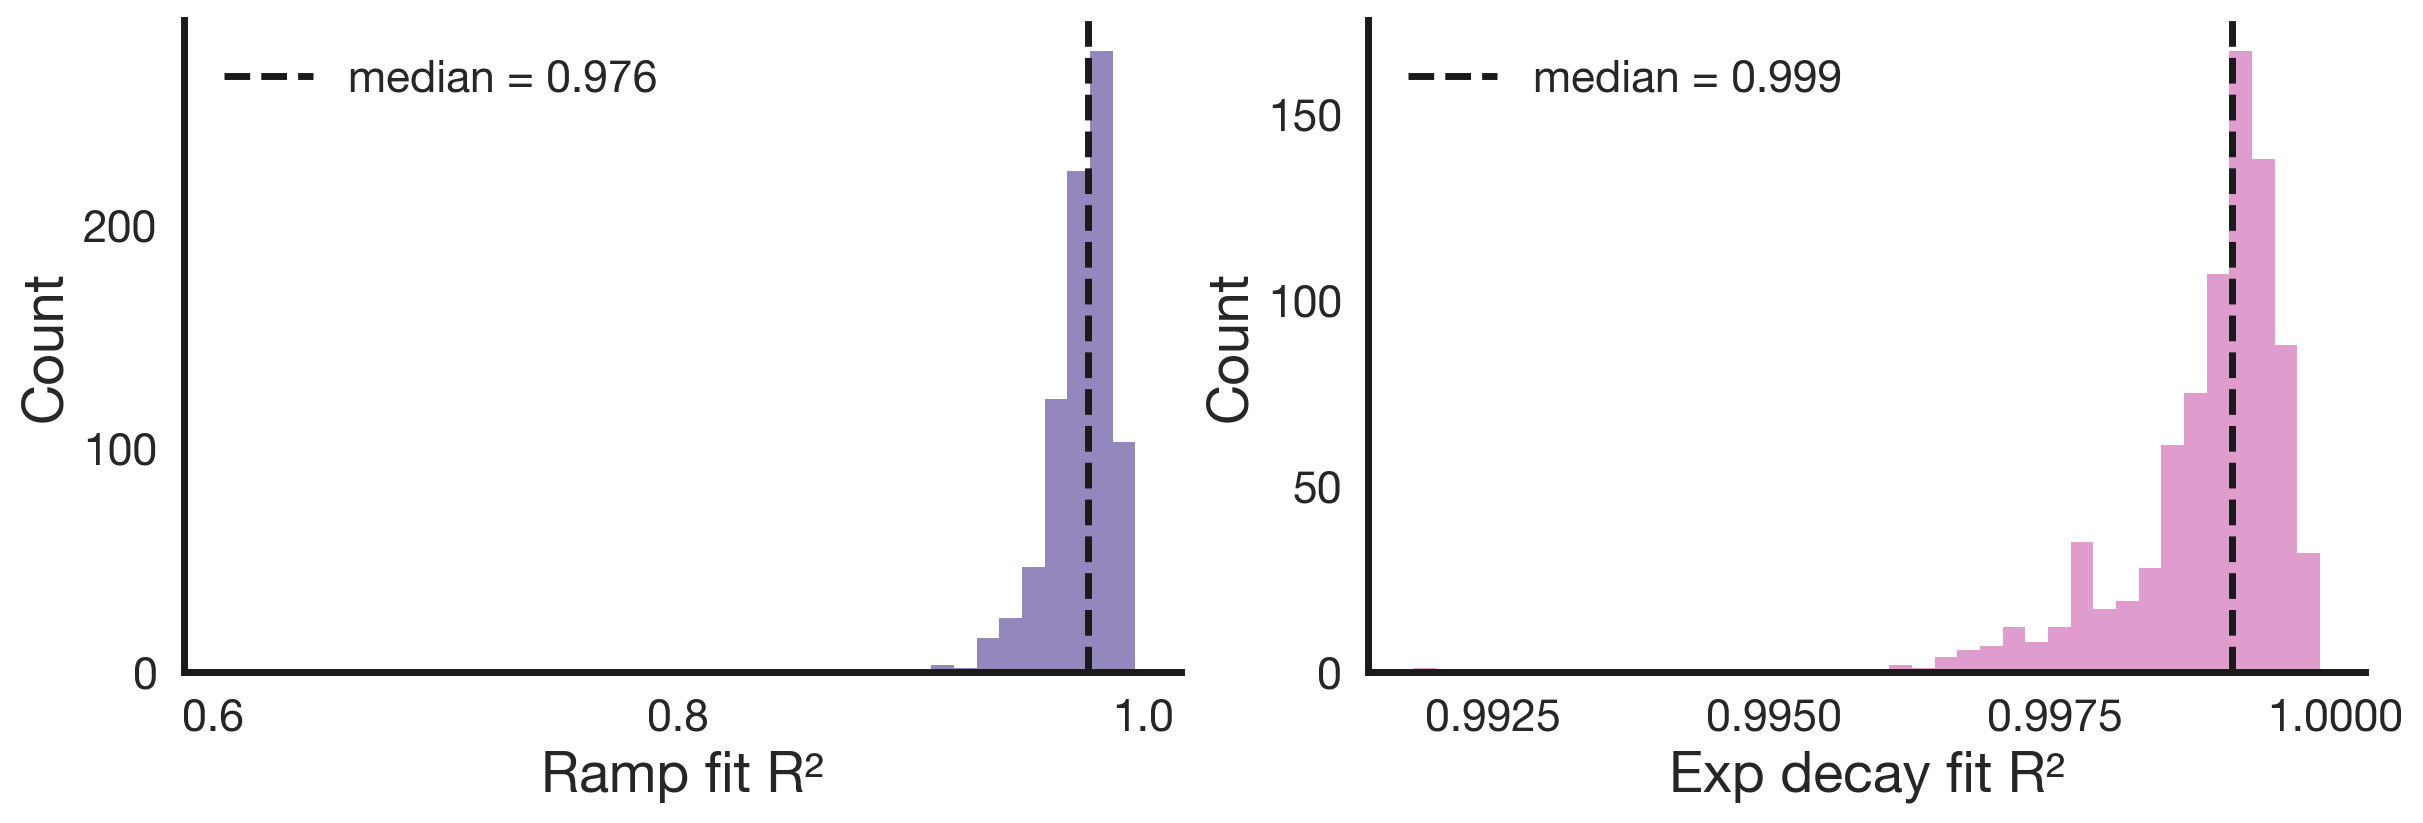

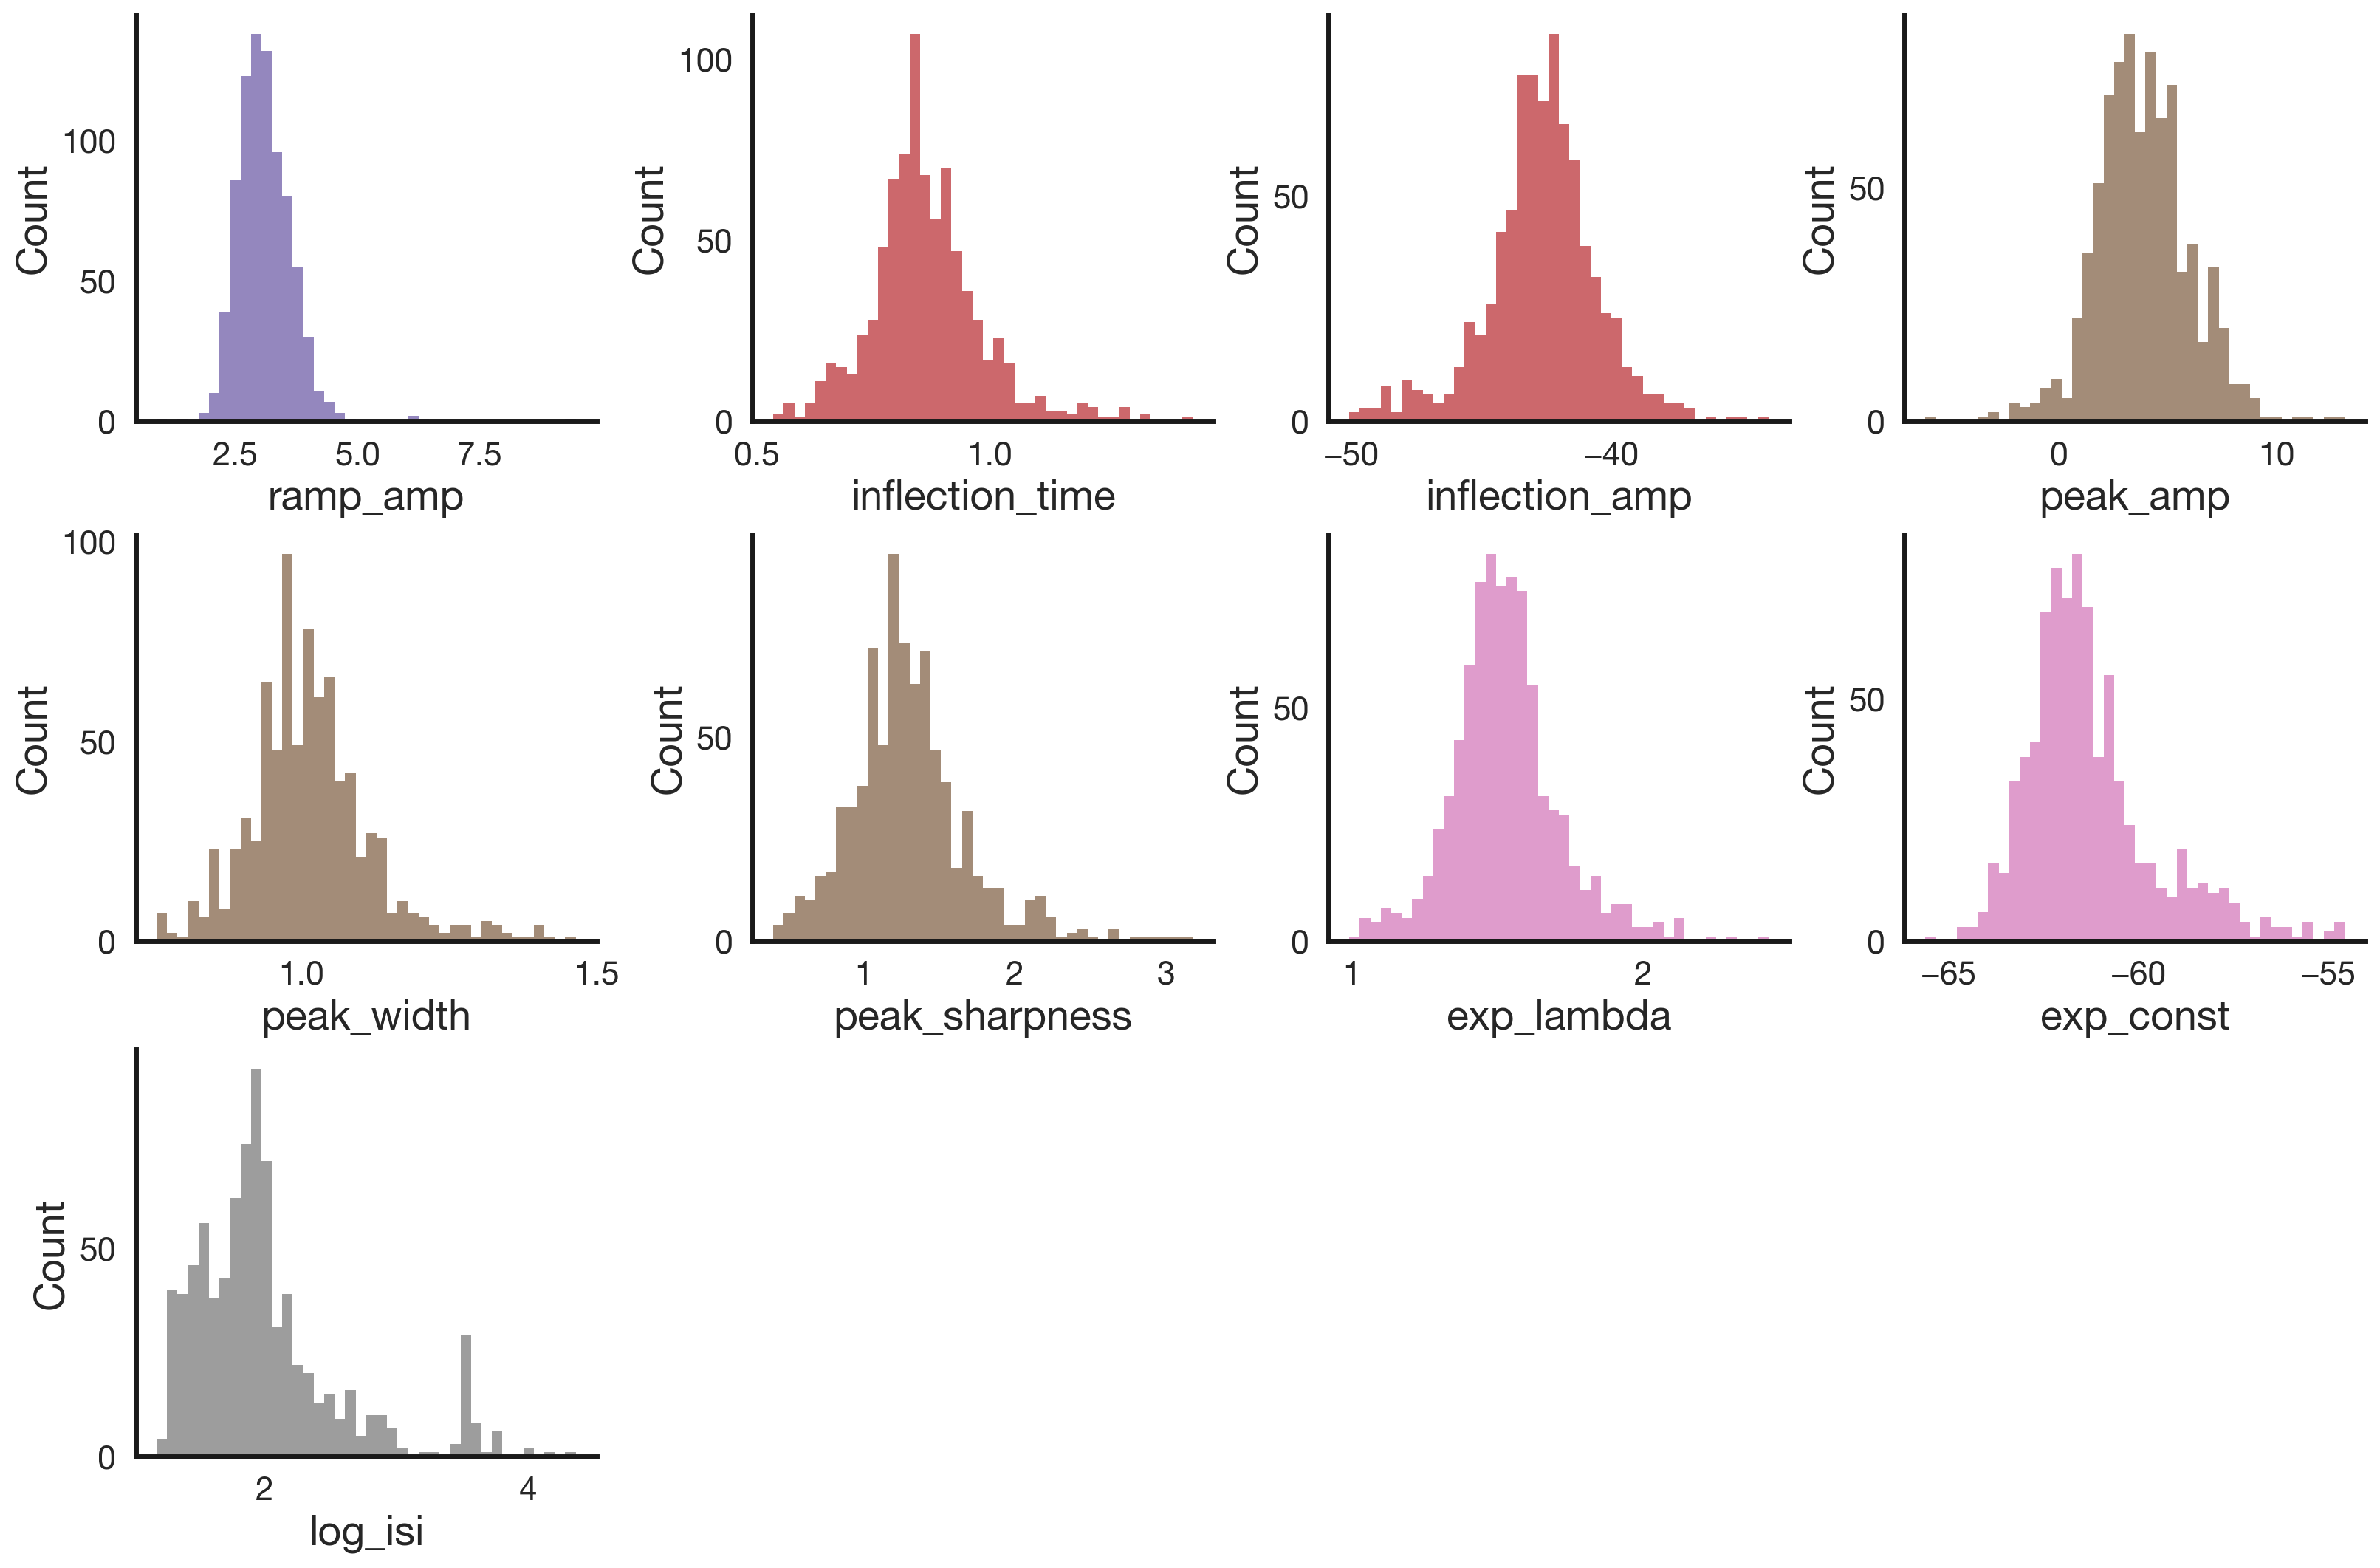

In [10]:
plot_fit_quality_distributions(sp)
plot_feature_histograms(df_features)


### 4c. Merging Spike Features with Stimulus Metadata

We concatenate the `Spike` feature DataFrame with the per-spike stimulus table, yielding one row per spike with both waveform parameters and stimulus context. From here we can ask: do waveform features differ across stim types, or co-vary continuously with instantaneous stimulus statistics?

In [11]:
df = pd.concat([df_stim_features, df_features], axis=1)
df = df.dropna(subset=['stim_type'])

### 5b. Pink Noise Spikes — Waveform Gallery

We plot the raw spike waveforms from pink noise sweeps only. Visualizing the spread of individual waveforms (rather than just the mean) shows us the within-condition variability that our models need to explain.

In [12]:
pink_spikes = df[df['stim_type'] == 'pink']

# Get the indices to plot
indices_to_plot = pink_spikes.index.tolist()

### 5c. Excluding Last-Spike-of-Sweep Artifacts

The last spike of each sweep is removed before regression analyses — these spikes often have inflated ISIs (no successor spike) that would skew the log ISI distribution and confound the predictors.

In [13]:
last_spikes_indices = df.groupby('sweep').tail(1).index
print("Indices of last spikes in each sweep:", last_spikes_indices)

Indices of last spikes in each sweep: Int64Index([  3,   9,  10,  11,  12,  13,  42,  45,  49,  56,  63,  64,  74,
             87,  98, 104, 132, 158, 185, 193, 194, 198, 204, 211, 212, 221,
            236, 249, 255, 279, 305, 331, 357, 358, 364, 371, 379, 385, 401,
            416, 431, 441, 470, 499, 529, 563, 577, 631, 722, 735, 769, 819],
           dtype='int64')


### 5e. Correlation Scatter Plots — Pink Spikes (Excluding Last-Sweep Spikes)

In [14]:
df_pink = df.loc[df['stim_type'] == 'pink']
# Find which indices are actually present in df_pink, remove last spike of sweeps
valid_indices = [idx for idx in last_spikes_indices if idx in df_pink.index]

# Drop the last spikes
df_pink_filtered = df_pink.drop(valid_indices)

df_pink_first = df_pink.loc[df_pink['spike_num'] == 0].copy()

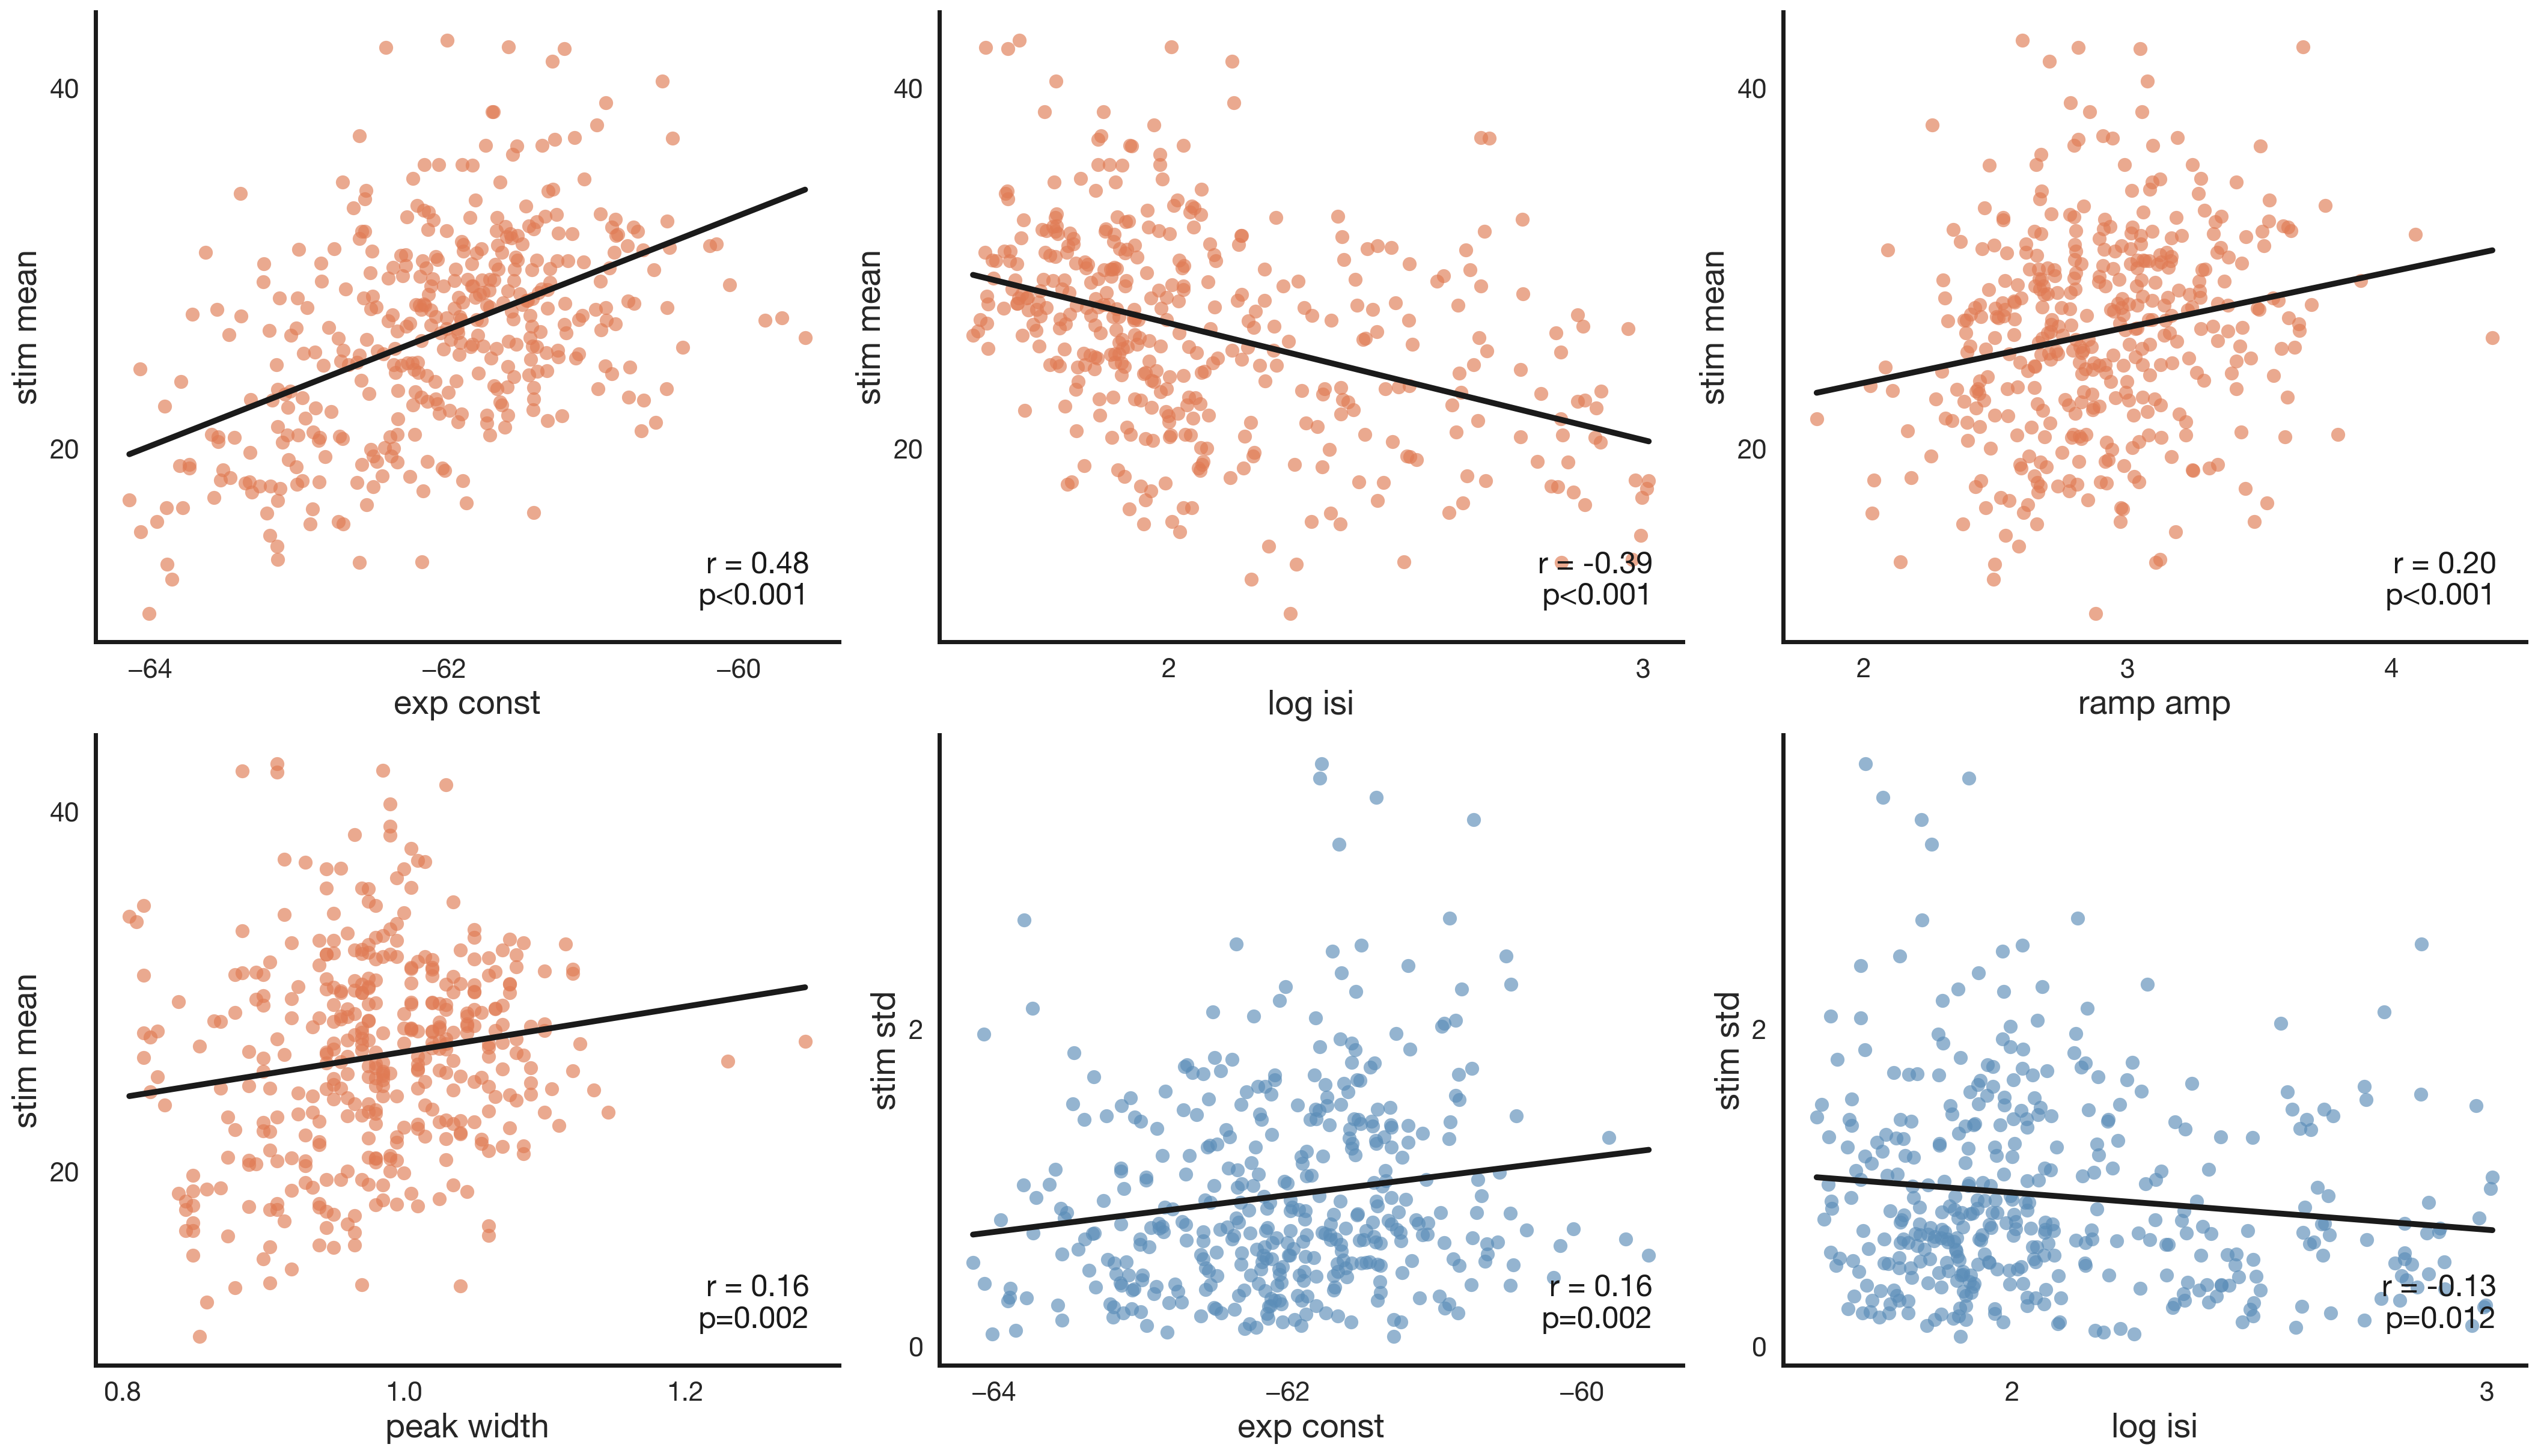

In [15]:
plot_top_correlations_by_window(df_pink_filtered, window_ms=5)


In [16]:
#get dfs for regression models 

df_pink_no_stim_filtered = df_pink_filtered.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_no_stim_first = df_pink_first.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_onlystim_filtered = df_pink_filtered.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)
df_pink_onlystim_first = df_pink_first.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)


## Supplementary Figures

### 2a. Constant Current — Baseline Waveform

An example sweep under constant DC injection. This is our control condition: the input is flat, so any spike-to-spike waveform variability here reflects intrinsic noise or adaptation, not stimulus-driven modulation.

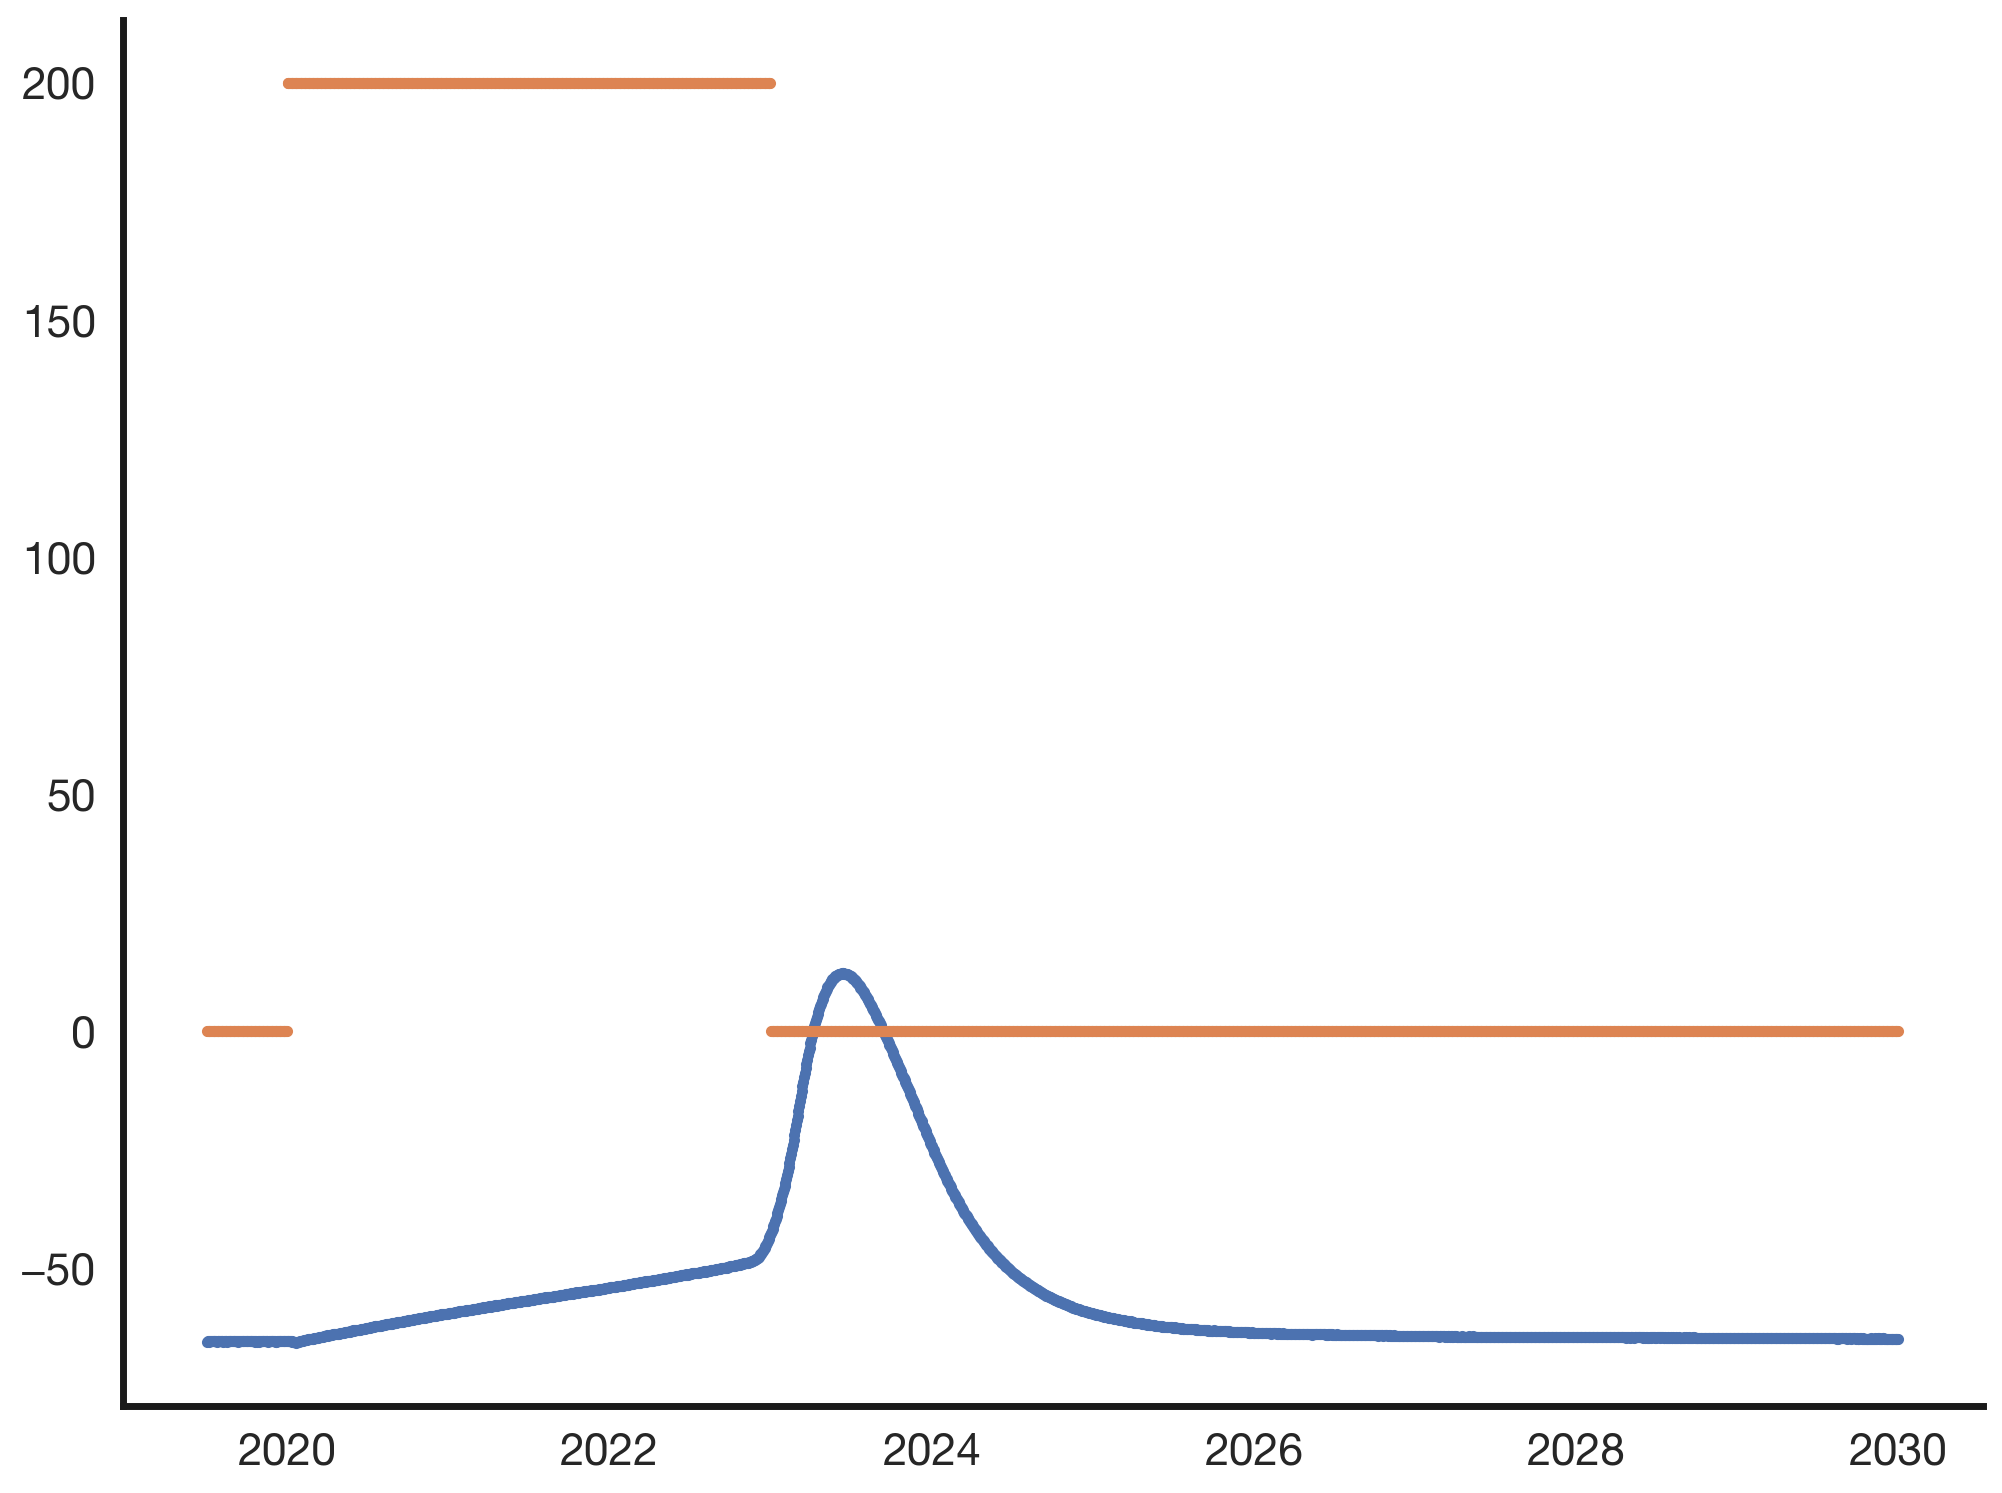

In [17]:
sweep_number = 3
index_start = 403900
index_end = 406000
dset, times = load_sweep(sweep_number, f, fs)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

### 2b. Pink Noise — Stimulus-Driven Variability

An example sweep under 1/f noise stimulation. The input fluctuates continuously, driving variable firing rates and — our central hypothesis — systematic changes in spike waveform shape that track the input statistics.

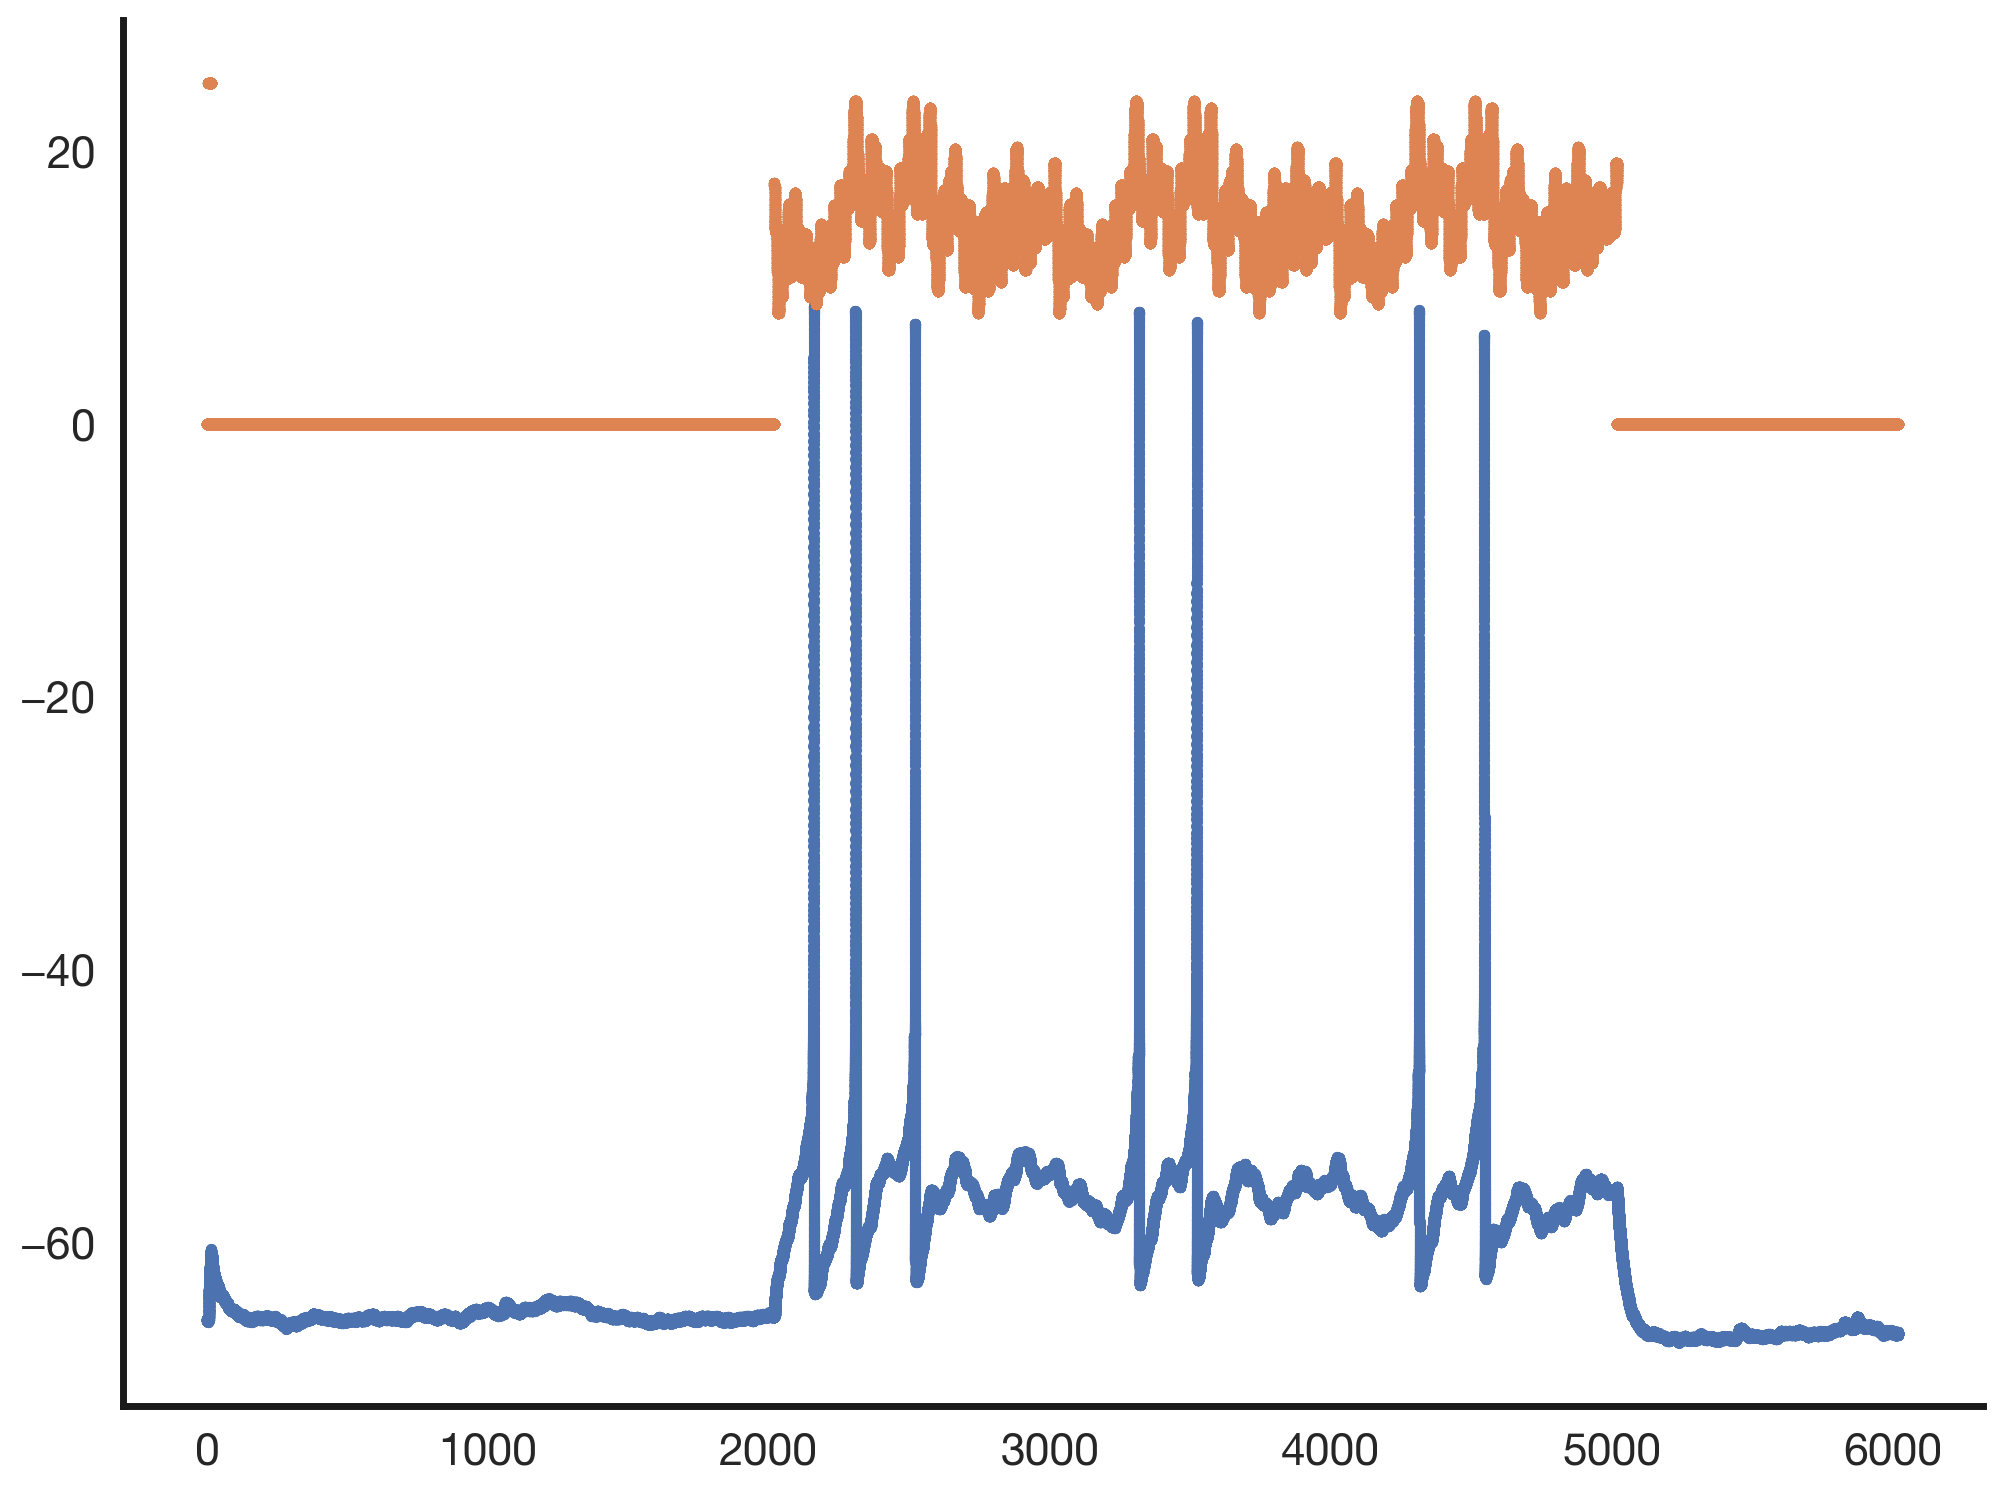

In [18]:
sweep_number = 14
index_start = 0
index_end = int(10e10)
dset, times = load_sweep(sweep_number, f, fs)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

In [19]:
all_contant_spks, all_ramp_spks, all_pink_spks = stim_waveforms[0], stim_waveforms[1], stim_waveforms[2]

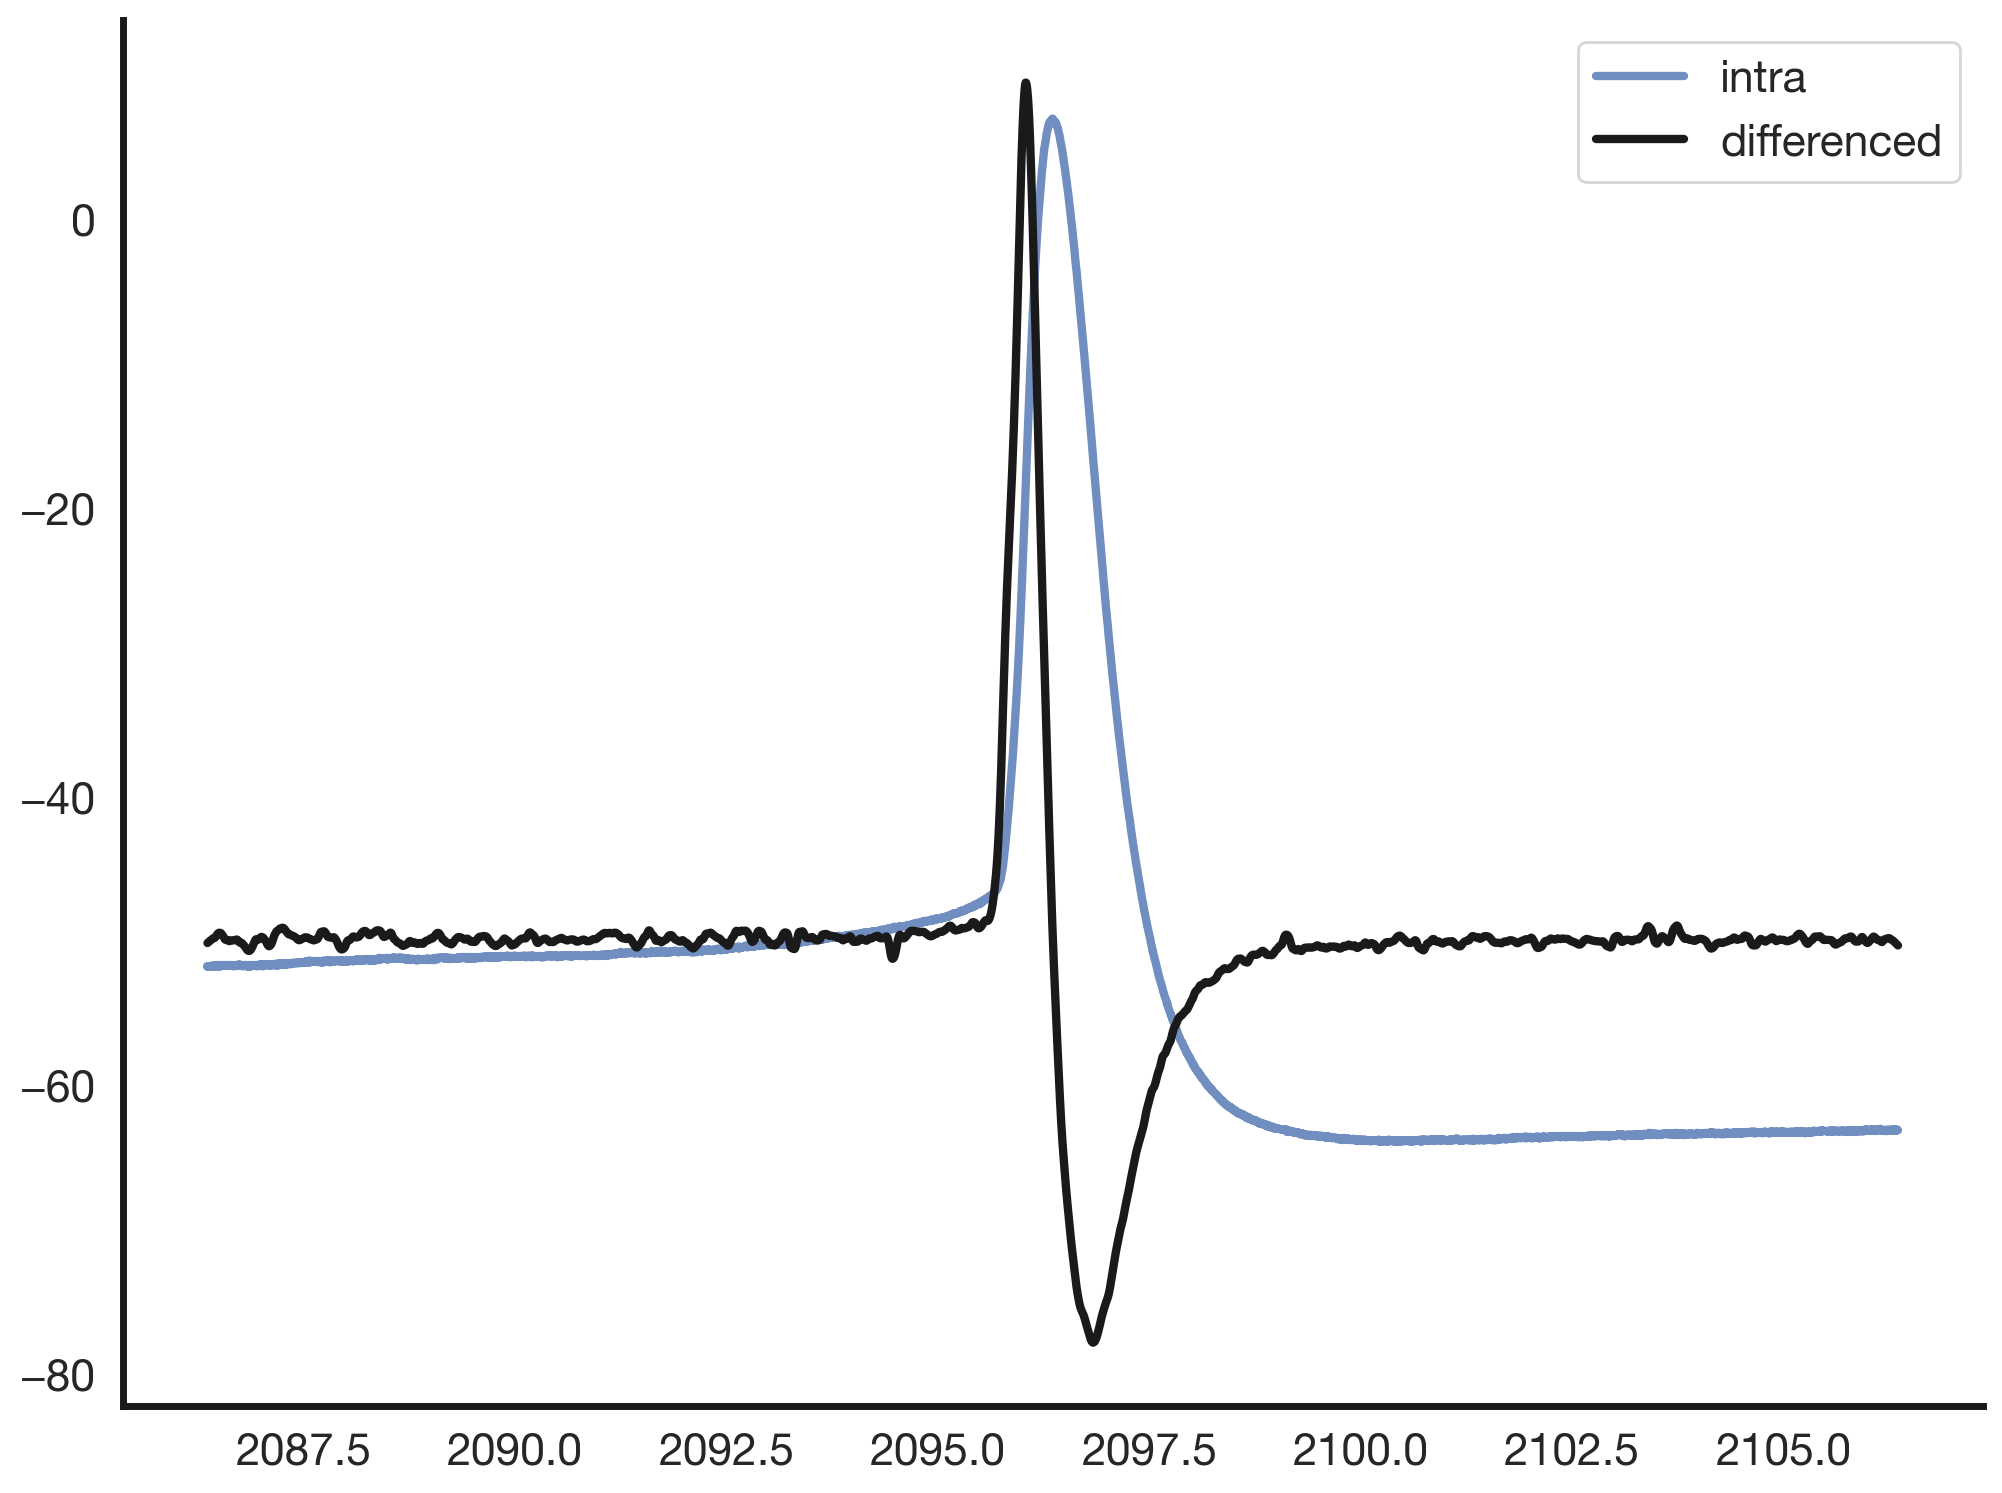

In [20]:
plot_spike_and_derivative(28, f, fs, one_ms)

## 5. Exploratory Analysis

### 5a. Average Waveform by Stimulus Type

Do spike shapes look systematically different across constant, ramp, and pink stimulation? This plot is the first visual check — if the mean waveforms differ across conditions, it's prima facie evidence that input drive shapes spike morphology.

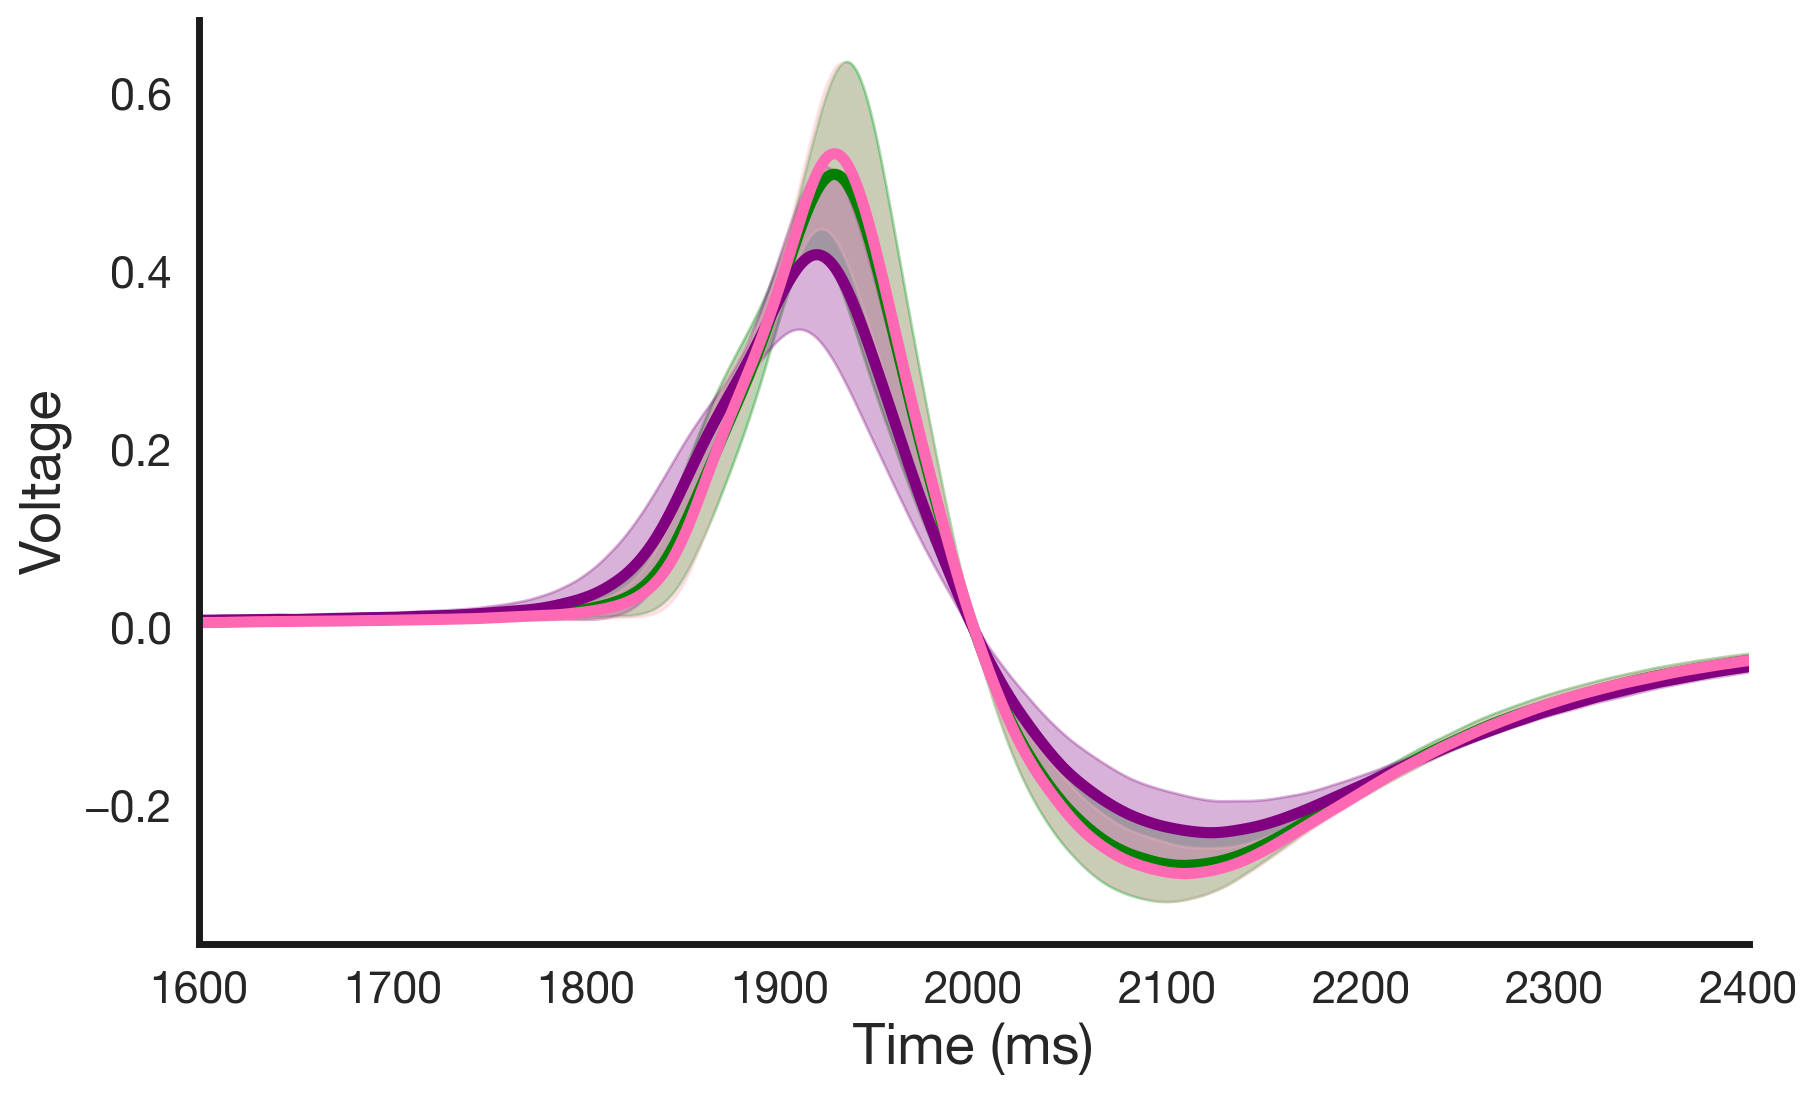

In [21]:
plot_avg_waveform_by_stim_type(all_contant_spks, all_ramp_spks,all_pink_spks)

#### i. All Spikes (constant + ramp + pink combined)

In [ ]:
df_all = df.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

with plt.rc_context(plt.rcParamsDefault):
    axes = pd.plotting.scatter_matrix(df_all, alpha=0.5, figsize=(12, 12))
    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha('right')
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')
    plt.tight_layout()
    plt.show()

plot_corr_heatmap_only_spk(df_all, list(df_all.columns))

rho  = df_all.corr()
pval = df_all.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p    = pval.applymap(lambda x: ''.join(['*' for t in [0.001, 0.01, 0.05] if x <= t]))
rho.round(2).astype(str) + p

#### ii. Pink Noise Spikes Only

In [ ]:
df_pink = df.loc[df['stim_type'] == 'pink']
df_pink = df_pink.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

with plt.rc_context(plt.rcParamsDefault):
    axes = pd.plotting.scatter_matrix(df_pink, alpha=0.5, figsize=(12, 12))
    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha('right')
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')
    plt.tight_layout()
    plt.show()

plot_corr_heatmap_only_spk(df_pink, list(df_pink.columns))

rho  = df_pink.corr()
pval = df_pink.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p    = pval.applymap(lambda x: ''.join(['*' for t in [0.001, 0.01, 0.05] if x <= t]))
rho.round(2).astype(str) + p

#### iii. First Spike per Pink Sweep — Minimizing Adaptation

In [ ]:
df_pink_first = df.loc[df['stim_type'] == 'pink']
df_pink_first = df_pink_first.loc[df['spike_num'] == 0]
df_pink_first = df_pink_first.drop(['sweep', 'stim_type', 'spike_num', 'pink_type'], axis=1)

with plt.rc_context(plt.rcParamsDefault):
    axes = pd.plotting.scatter_matrix(df_pink_first, alpha=0.5, figsize=(12, 12))
    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha('right')
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')
    plt.tight_layout()
    plt.show()

plot_corr_heatmap_only_spk(df_pink_first, list(df_pink_first.columns))

rho  = df_pink_first.corr()
pval = df_pink_first.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p    = pval.applymap(lambda x: ''.join(['*' for t in [0.001, 0.01, 0.05] if x <= t]))
rho.round(2).astype(str) + p

In [25]:
# Calculate the number of spikes in each sweep
spike_counts = df.groupby('sweep')['spike_num'].count()

# Calculate the duration of each sweep in seconds using the indices from spike_counts
sweep_durations = {sweep: f[f"Sweep_{int(sweep)}"].shape[0] / fs for sweep in spike_counts.index}

# Calculate the firing rate for each sweep
firing_rates = {sweep: spike_counts[sweep] / sweep_durations[sweep] for sweep in spike_counts.index}

# Convert the dictionary to a DataFrame for easier handling and visualization
firing_rate_df = pd.DataFrame(list(firing_rates.items()), columns=['Sweep', 'Firing Rate'])

# Extract 'stim_type' values for each unique 'sweep'
stim_type_series = df.groupby('sweep')['stim_type'].first()
# Add the 'stim_type' to the firing_rate_df
firing_rate_df['Stim Type'] = firing_rate_df['Sweep'].map(stim_type_series)

# Display the updated DataFrame
print(firing_rate_df)

    Sweep  Firing Rate Stim Type
0       0     0.569800      ramp
1       1     0.854700      ramp
2       3     0.330797  constant
3       4     0.330797  constant
4       6     0.330797  constant
5       7     0.330797  constant
6      11     7.213921  constant
7      12     0.746268  constant
8      13     0.664451      pink
9      14     1.162790      pink
10     15     1.162790      pink
11     16     0.166113  constant
12     17     1.661128      pink
13     18     2.159467      pink
14     19     1.827241      pink
15     20     0.996677  constant
16     21     4.651159      pink
17     22     4.318933      pink
18     23     4.485046      pink
19     24     1.328903  constant
20     27     0.330797  constant
21     28     0.664451      pink
22     29     0.996677      pink
23     30     1.162790      pink
24     31     0.166113  constant
25     32     1.495015      pink
26     33     2.491692      pink
27     34     2.159467      pink
28     35     0.996677  constant
29     36 

## 8. Regression: Predicting Log ISI

Log ISI is a proxy for instantaneous firing rate — a direct readout of neural drive. We fit three ridge regression models: (1) spike waveform features only, (2) stimulus features only, (3) both combined. Comparing R² across models tells us how much of firing rate variability is explained by waveform shape alone, whether the stimulus adds independent information, and whether waveform features are essentially redundant with the stimulus signal.

### 8a. Model 1 — Spike Waveform Features Only

In [26]:
y_log_isi = df_pink_filtered['log_isi']

pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_spike_only.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_spike_only = pickle.load(file)
    print('Loaded ridge_results_spike_only from pickle.')
else:
    X_spike_only = df_pink_filtered.drop(columns=['log_isi', 'stim_exp', 'stim_mean', 'stim_std'])
    ridge_results_spike_only = run_ridge_regression_kfold(X_spike_only, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_spike_only, file)
    print('Saved ridge_results_spike_only to pickle.')

Loaded ridge_results_spike_only from pickle.


In [27]:
plot_ridge_results_grid(
    {'M1_spike_only': ridge_results_spike_only,
     'M2_spike_stim': ridge_results_spike_stim,
     'M3_stim_only':  ridge_results_stim_only},
    keys=['M1_spike_only', 'M2_spike_stim', 'M3_stim_only'],
    labels=['Spike only', 'Spike + stim', 'Stim only'],
    ys={'M1_spike_only': y_log_isi,
        'M2_spike_stim': y_log_isi,
        'M3_stim_only':  y_log_isi},
)


NameError: name 'ridge_results_spike_stim' is not defined

### 8b. Model 2 — Spike + Stimulus Features

In [ ]:
pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_spike_stim.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_spike_stim = pickle.load(file)
    print('Loaded ridge_results_spike_stim from pickle.')
else:
    X_spike_stim = df_pink_filtered.drop(columns=['log_isi'])
    ridge_results_spike_stim = run_ridge_regression_kfold(X_spike_stim, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_spike_stim, file)
    print('Saved ridge_results_spike_stim to pickle.')

In [ ]:
# See combined grid above.

### 8c. Model 3 — Stimulus Features Only

In [ ]:
pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_stim_only.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_stim_only = pickle.load(file)
    print('Loaded ridge_results_stim_only from pickle.')
else:
    X_stim_only = df_pink_filtered[['stim_exp', 'stim_mean', 'stim_std']]
    ridge_results_stim_only = run_ridge_regression_kfold(X_stim_only, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_stim_only, file)
    print('Saved ridge_results_stim_only to pickle.')

In [ ]:

# FDR correction across ISI models (M1 / M2 / M3)
apply_fdr_pvc6({'M1_spike_only': ridge_results_spike_only,
                'M2_spike_stim': ridge_results_spike_stim,
                'M3_stim_only':  ridge_results_stim_only})

### 8d. Model Comparison

Side-by-side R² with bootstrapped CIs for all three models. If the waveform-only model approaches the combined model's performance, it means spike shape is already capturing most of the stimulus-relevant variance — consistent with waveform features being a faithful readout of instantaneous input drive.

In [ ]:
#Set up dataframes for plotting 

feature_importance_spike_only_df = pd.DataFrame({'Feature': ridge_results_spike_only['feature_names'], 'Coefficient': ridge_results_spike_only['coefficients']})
feature_importance_spike_stim_df = pd.DataFrame({'Feature': ridge_results_spike_stim['feature_names'], 'Coefficient': ridge_results_spike_stim['coefficients']})
feature_importance_stim_only_df = pd.DataFrame({'Feature': ridge_results_stim_only['feature_names'], 'Coefficient': ridge_results_stim_only['coefficients']})

feature_importance_spike_only_df['Model'] = 'No stim features'
feature_importance_spike_stim_df['Model'] = 'With stim features (Combined)'
feature_importance_stim_only_df['Model'] = 'Only stim features'

In [ ]:
#Plot comparisons
plot_r2_comparison(ridge_results_spike_only, ridge_results_spike_stim, ridge_results_stim_only)
plot_combined_actual_vs_predicted(y_log_isi, ridge_results_spike_only['y_pred_cv'], ridge_results_spike_stim['y_pred_cv'], ridge_results_stim_only['y_pred_cv'])
plot_combined_feature_importance(feature_importance_spike_only_df, feature_importance_spike_stim_df, feature_importance_stim_only_df)


### 8e. F-Test — Does Adding Stimulus Features Significantly Improve ISI Prediction?

Formal test of whether the combined model (waveform + stimulus) explains significantly more variance in log ISI than the waveform-only model. A non-significant result would suggest waveform features are already sufficient — waveform shape captures the stimulus information that matters for firing dynamics.

In [ ]:
adjs_rsq_spk = ridge_results_spike_only["r2_mean"]
adjs_rsq_stim =ridge_results_stim_only["r2_mean"]
adjs_rsq_spk_stim =ridge_results_spike_stim["r2_mean"]

In [ ]:
# Number of features
p_spk = 8
p_stim = 3
p_spk_stim = 11

# Sample size
n = 391

def f_test_r2(adj_r2_small, adj_r2_big, p_small, p_big, n):
    num = (adj_r2_big - adj_r2_small) / (p_big - p_small)
    denom = (1 - adj_r2_big) / (n - p_big - 1)
    F = num / denom
    df1 = p_big - p_small
    df2 = n - p_big - 1
    p = 1 - stats.f.cdf(F, df1, df2)
    return F, p

# Compare all pairs
f_spk_vs_stim = f_test_r2(adjs_rsq_stim, adjs_rsq_spk, p_stim, p_spk, n)
f_spk_vs_combined = f_test_r2(adjs_rsq_spk, adjs_rsq_spk_stim, p_spk, p_spk_stim, n)
f_stim_vs_combined = f_test_r2(adjs_rsq_stim,adjs_rsq_spk_stim, p_stim, p_spk_stim, n)

print("Spike vs. Stim:", f_spk_vs_stim)
print("Spike vs. Combined:", f_spk_vs_combined)
print("Stim vs. Combined:", f_stim_vs_combined)